Epoch 1/10


C:\Users\aksha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - age_loss: 3693.3635 - age_mae: 60.7730 - gender_accuracy: 0.0000e+00 - gender_loss: 0.7200 - loss: 3694.0835 - val_age_loss: 2699.1431 - val_age_mae: 51.9533 - val_gender_accuracy: 1.0000 - val_gender_loss: 0.4253 - val_loss: 2699.5684
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - age_loss: 3235.2334 - age_mae: 56.8791 - gender_accuracy: 1.0000 - gender_loss: 0.0241 - loss: 3235.2576 - val_age_loss: 1508.0997 - val_age_mae: 38.8343 - val_gender_accuracy: 1.0000 - val_gender_loss: 0.0374 - val_loss: 1508.1371
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - age_loss: 1818.4753 - age_mae: 42.6436 - gender_accuracy: 1.0000 - gender_loss: 0.0044 - loss: 1818.4797 - val_age_loss: 459.2296 - val_age_mae: 21.4296 - val_gender_accuracy: 1.0000 - val_gender_loss: 7.6289e-04 - val_loss: 459.2303
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - age_loss: 510.4688 - age_mae: 22.5936 - gender_accuracy: 0.0000e+00 - gender_loss: 4.2708 - loss: 514.73

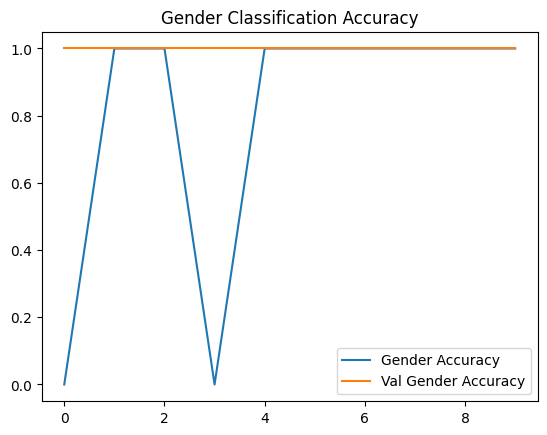

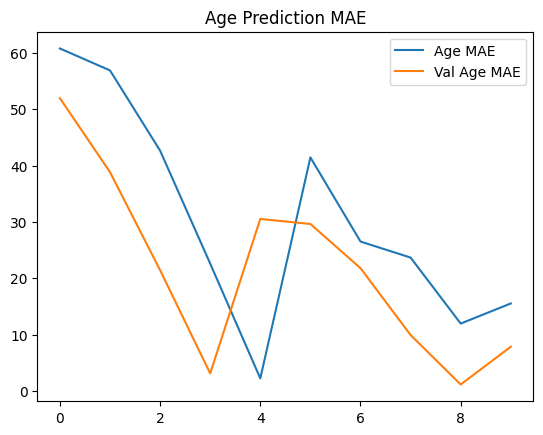

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted Gender: Female
Predicted Age: 53
Actual Gender: Female
Actual Age: 61


C:\Users\aksha\AppData\Local\Temp\ipykernel_3592\608819111.py:124: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Predicted Age:", int(pred_age[0]))


In [1]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


image_dir = r"C:\Users\aksha\OneDrive\Desktop\hi\op\crop_part1"  # Replace with your folder path
image_files = os.listdir(image_dir)

data = []

for file in image_files:
    if file.endswith('.jpg') or file.endswith('.png'):
        try:
            age, gender, _ = file.split('_')  # e.g., 25_male_001.jpg
            data.append([file, int(age), 0 if gender.lower() == 'male' else 1])  # male: 0, female: 1
        except:
            continue  # skip bad filenames

df = pd.DataFrame(data, columns=["filename", "age", "gender"])
df['image_path'] = df['filename'].apply(lambda x: os.path.join(image_dir, x))

IMG_SIZE = (100, 100)

images = []
ages = []
genders = []

for index, row in df.iterrows():
    try:
        img = load_img(row['image_path'], target_size=IMG_SIZE)
        img = img_to_array(img) / 255.0  # normalize
        images.append(img)
        ages.append(row['age'])
        genders.append(row['gender'])
    except:
        continue  # skip unreadable images

X = np.array(images)
y_age = np.array(ages)
y_gender = to_categorical(genders, num_classes=2)

# === Step 3: Split dataset ===
X_train, X_test, y_age_train, y_age_test, y_gender_train, y_gender_test = train_test_split(
    X, y_age, y_gender, test_size=0.2, random_state=42)

# === Step 4: Build CNN Model ===
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(*IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5)
])


from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Input
input_layer = Input(shape=(*IMG_SIZE, 3))

# Shared CNN Base
x = Conv2D(32, (3, 3), activation='relu')(input_layer)
x = MaxPooling2D()(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D()(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)


gender_output = Dense(2, activation='softmax', name='gender')(x)

age_output = Dense(1, activation='linear', name='age')(x)


multi_model = Model(inputs=input_layer, outputs=[gender_output, age_output])

# Compile
multi_model.compile(
    optimizer=Adam(),
    loss={'gender': 'categorical_crossentropy', 'age': 'mse'},
    metrics={'gender': 'accuracy', 'age': 'mae'}
)


history = multi_model.fit(
    X_train,
    {'gender': y_gender_train, 'age': y_age_train},
    validation_data=(X_test, {'gender': y_gender_test, 'age': y_age_test}),
    epochs=10,
    batch_size=32
)


plt.plot(history.history['gender_accuracy'], label='Gender Accuracy')
plt.plot(history.history['val_gender_accuracy'], label='Val Gender Accuracy')
plt.legend()
plt.title("Gender Classification Accuracy")
plt.show()

plt.plot(history.history['age_mae'], label='Age MAE')
plt.plot(history.history['val_age_mae'], label='Val Age MAE')
plt.legend()
plt.title("Age Prediction MAE")
plt.show()
i = 0  # Test image index
sample = np.expand_dims(X_test[i], axis=0)
pred_gender, pred_age = multi_model.predict(sample)

print("Predicted Gender:", "Male" if np.argmax(pred_gender) == 0 else "Female")
print("Predicted Age:", int(pred_age[0]))
print("Actual Gender:", "Male" if np.argmax(y_gender_test[i]) == 0 else "Female")
print("Actual Age:", y_age_test[i])